# Compute Reliability Score 

This notebook is used to assess the quality of the geocoded dataset through the computation of the reliability score. The reliability score (0–4) measures the level of agreement between geocoded locations obtained from GADM, OpenStreetMap, and Wikidata, where 0 indicates no available location, 1 a single source, 2 multiple sources without agreement, 3 agreement between at least two sources, and 4 full agreement across all three sources with spatial overlap and containment. The notebook is used to:
- Load GADM geometries at ADMIN1 level
- Compute the reliability score using the function `calculate_reliability`
- Produce pie chart and geospatial map to visualise the distribution of the reliability 

Requirements:
- `config.toml` must define paths: `geocoding.gadm_preprocessed_path`.
- `reliability_db.csv` must be present in the `./data` folder


The notenook produces the following figures in the manuscript: 
- Figure C1
- Figure C2


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import pycountry 
import os
import matplotlib.patches as mpatches
import tomllib
with open("config.toml", "rb") as f:
    config = tomllib.load(f)


In [2]:

def read_admin(path_admin,adl):
    adms=gpd.read_file(path_admin, layer=f"ADM_{adl}")
    
    adms = adms.rename(columns={'GID_0': 'iso3'})
    iso3_mapping = {'Z01':'IND', 'Z02':'CHN', 'Z03':'CHN', 'Z04':'IND', 'Z05':'IND', 'Z06':'PAK', 'Z07':'IND', 'Z08':'CHN', 'Z09':'IND'}
    adms["iso3"] = adms["iso3"].replace(iso3_mapping)
    adms = adms[~adms["iso3"].isin(["XKO",None])]
    pyi3=[pycountry.countries.get(alpha_3=i3) for i3 in adms.iso3]
    adms=adms[[x is not None for x in pyi3]] # som admin2 will be deleted belonging to ['China', 'India', 'Pakistan', 'Kosovo'] as they are in conflicted areas
    adms["iso2"]=[pycountry.countries.get(alpha_3=i3).alpha_2 for i3 in adms.iso3]

    adms["ADMIN0"]=adms["COUNTRY"]
    if adl ==1:
        adms["ADMIN1"]=adms["NAME_1"]
    elif adl ==2:
        adms["ADMIN1"]=adms["NAME_1"]
        adms["ADMIN2"]=adms["NAME_2"]
    
    
    return adms

gadm1 = read_admin(config["geocoding"]["gadm_preprocessed_path"], 1)
gadm1 = gadm1[gadm1["iso3"] != "ATA"]  # Antarctica: no disaster locations, left out of the maps

In [3]:
def calculate_reliability(row):
    gadm = row['gadm_count']
    osm = row['osm_count']
    wiki = row['wiki_count']
    overlap = row['gadm_osm_overlap_pct'] is not None and row['gadm_osm_overlap_pct'] > 50
    wiki_in_gadm = row['wiki_in_gadm'] == 1
    wiki_in_osm = row['wiki_in_osm'] == 1

    if gadm and osm and wiki:
        if overlap and wiki_in_gadm and wiki_in_osm:
            return 4  # Full agreement
        elif overlap or (wiki_in_gadm and wiki_in_osm):
            return 3  # High agreement
        else:
            return 2  # All available, but not all agree
    elif (gadm and osm and overlap) or (gadm and wiki and wiki_in_gadm) or (osm and wiki and wiki_in_osm):
        return 3  # Two agree
    elif (gadm and osm) or (gadm and wiki) or (osm and wiki):
        return 2  # Two available, not necessarily agree
    elif gadm or osm or wiki:
        return 1  # Only one available
    else:
        return 0  # None available


In [4]:
llmgeodis = pd.read_csv("./data/reliability_db.csv")

In [5]:
llmgeodis['reliability'] = llmgeodis.apply(calculate_reliability, axis=1)


In [6]:
llmgeodis["gadm_osm_overlap_pct"].mean()

np.float64(86.3979580149035)

In [7]:
llmgeodis["wiki_in_gadm"].value_counts(normalize=True)


wiki_in_gadm
1.0    0.886656
0.0    0.113344
Name: proportion, dtype: float64

In [8]:
llmgeodis["wiki_in_osm"].value_counts(normalize=True)


wiki_in_osm
1.0    0.857969
0.0    0.142031
Name: proportion, dtype: float64

In [9]:
llmgeodis.reliability.value_counts()

reliability
3    29997
1     8489
4     8453
2     4410
Name: count, dtype: int64

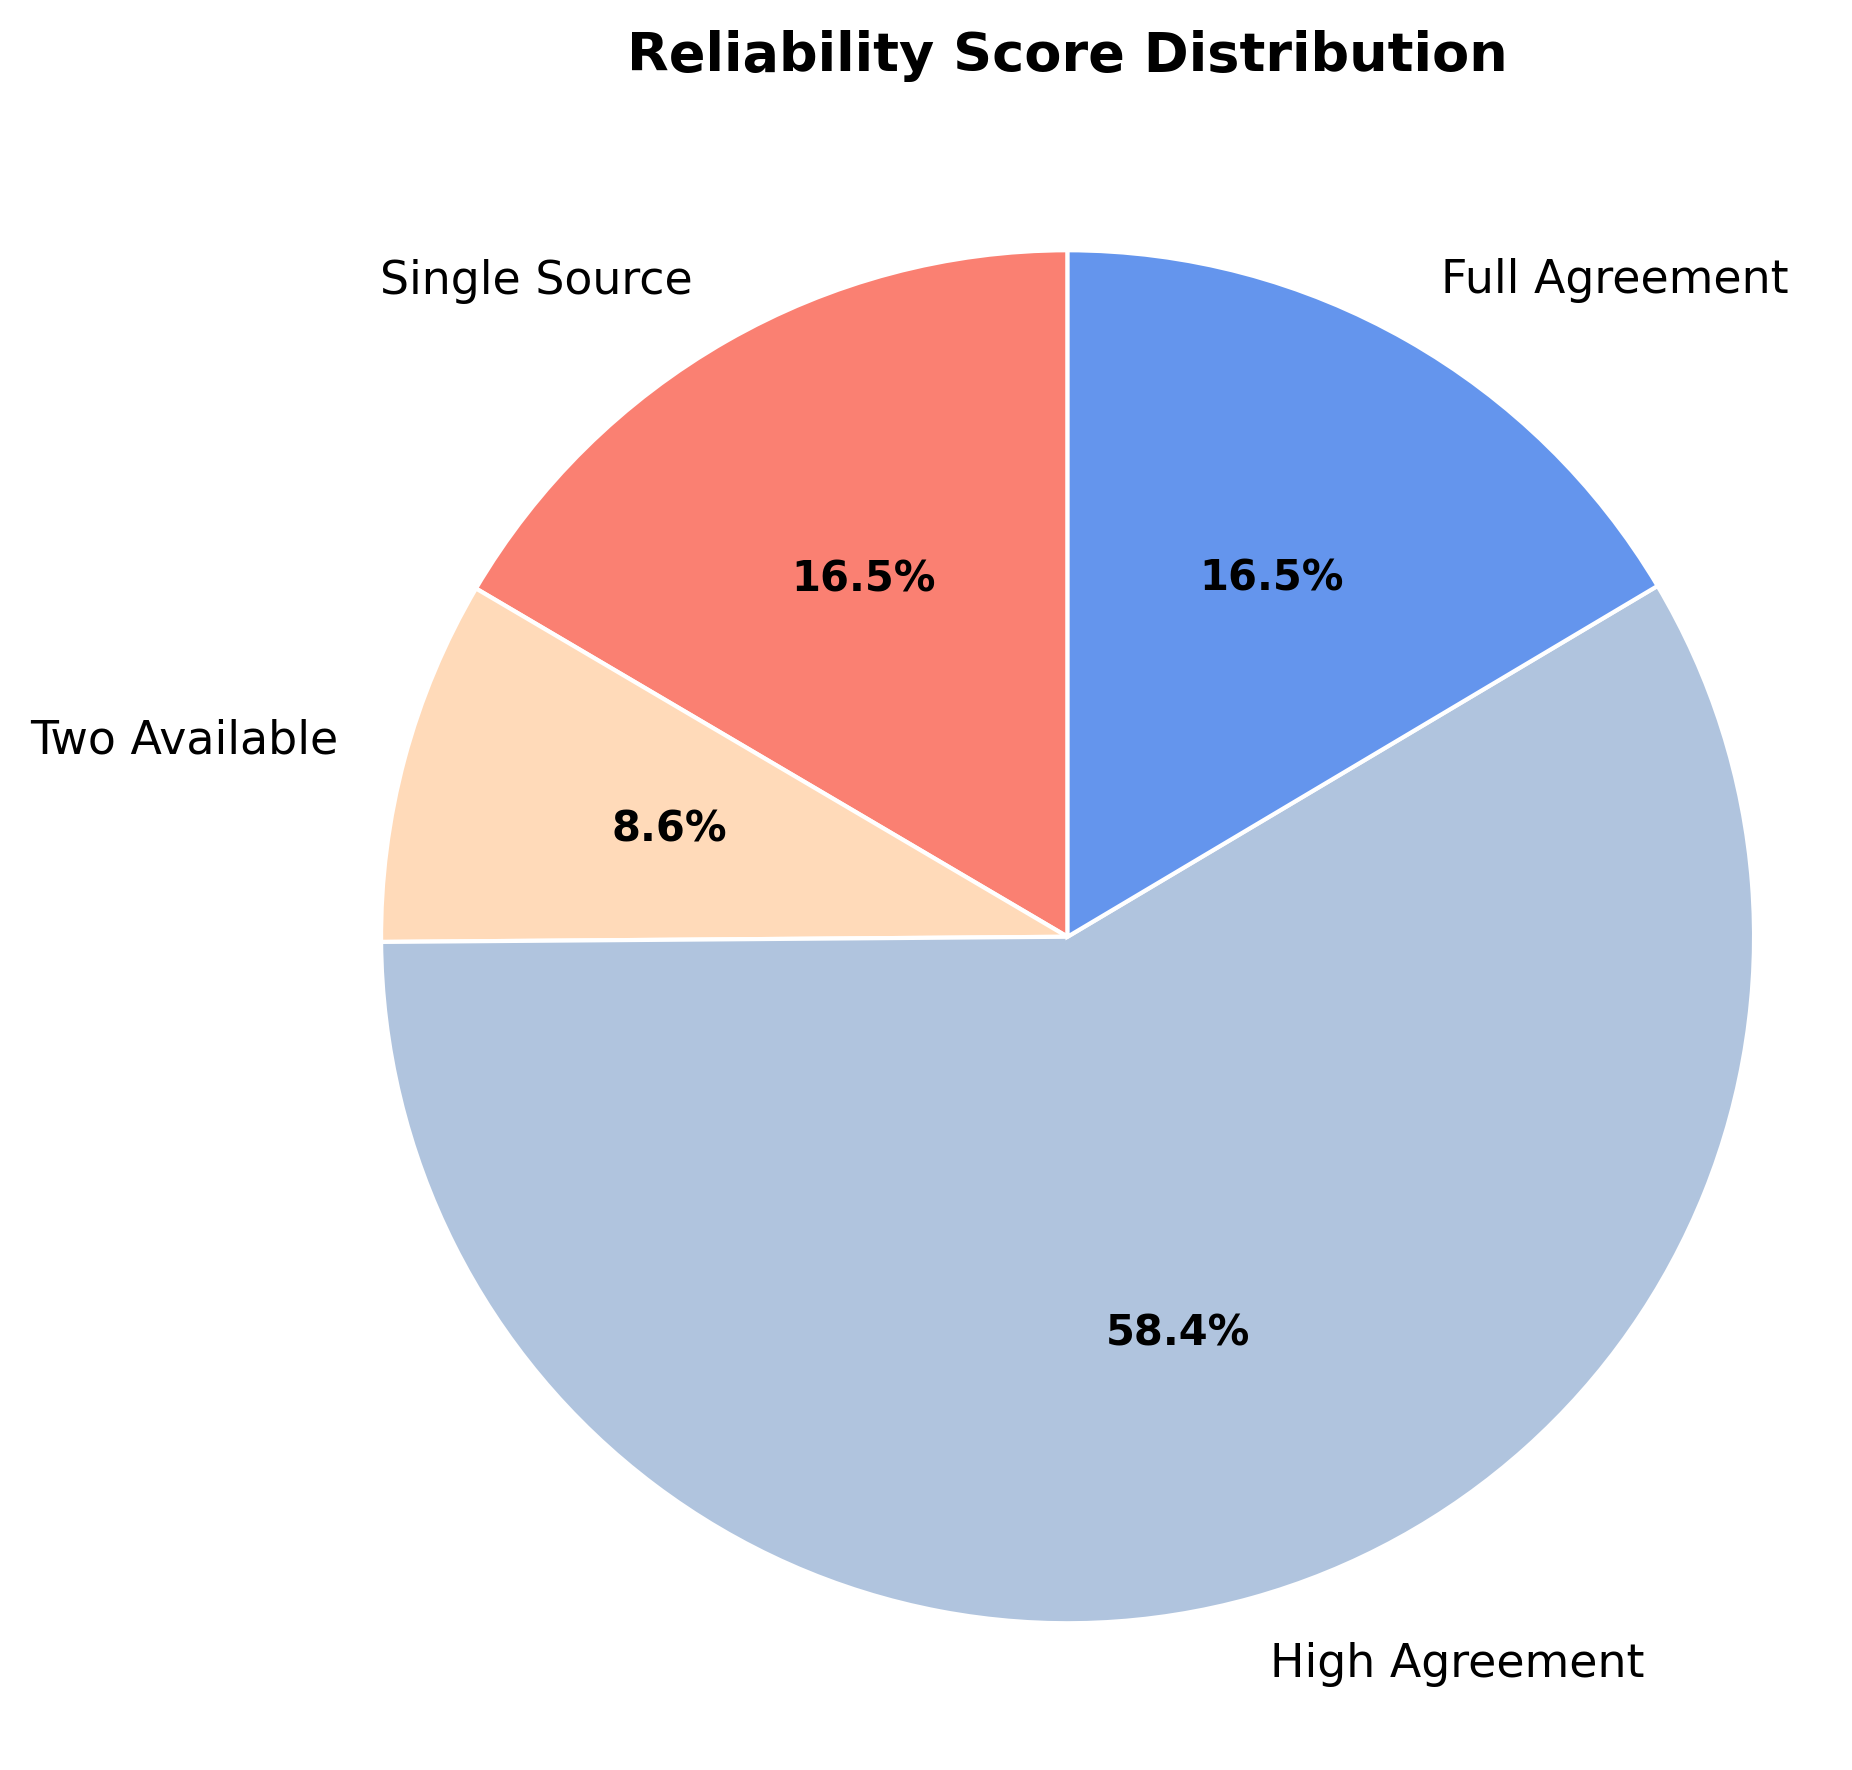

In [10]:


# Number of locations per reliability score (1 to 4)
reliability_counts = llmgeodis["reliability"].value_counts().reindex([1, 2, 3, 4], fill_value=0).to_dict()

# Define concise labels
labels = [
    'Single Source', 
    'Two Available', 
    'High Agreement', 
    'Full Agreement'
]

# Define specific colors for each category
colors = ['salmon', 'peachpuff', 'lightsteelblue', 'cornflowerblue']
# Create the figure
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

wedges, texts, autotexts = ax.pie(
    reliability_counts.values(),
    labels=labels, 
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 11, 'color': 'black'},
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(10)
    autotext.set_weight('bold')

ax.set_title(
    'Reliability Score Distribution',
    fontsize=13,
    weight='semibold',
    pad=15
)
plt.tight_layout()

ax.axis('equal')
plt.show()


In [11]:
llmgeodis["iso3"] = llmgeodis['DisNo.'].str.split('-').str[-1]

In [12]:
gadm1 = gadm1.rename(columns={"NAME_1":"admin1"})

In [13]:
relmap = llmgeodis[["reliability", "iso3", "admin1"]]
grouped_relmap = relmap.groupby(['iso3', 'admin1'], as_index=False).max()

In [14]:
rel = pd.merge(grouped_relmap, gadm1, on=["iso3", "admin1"], how="left")

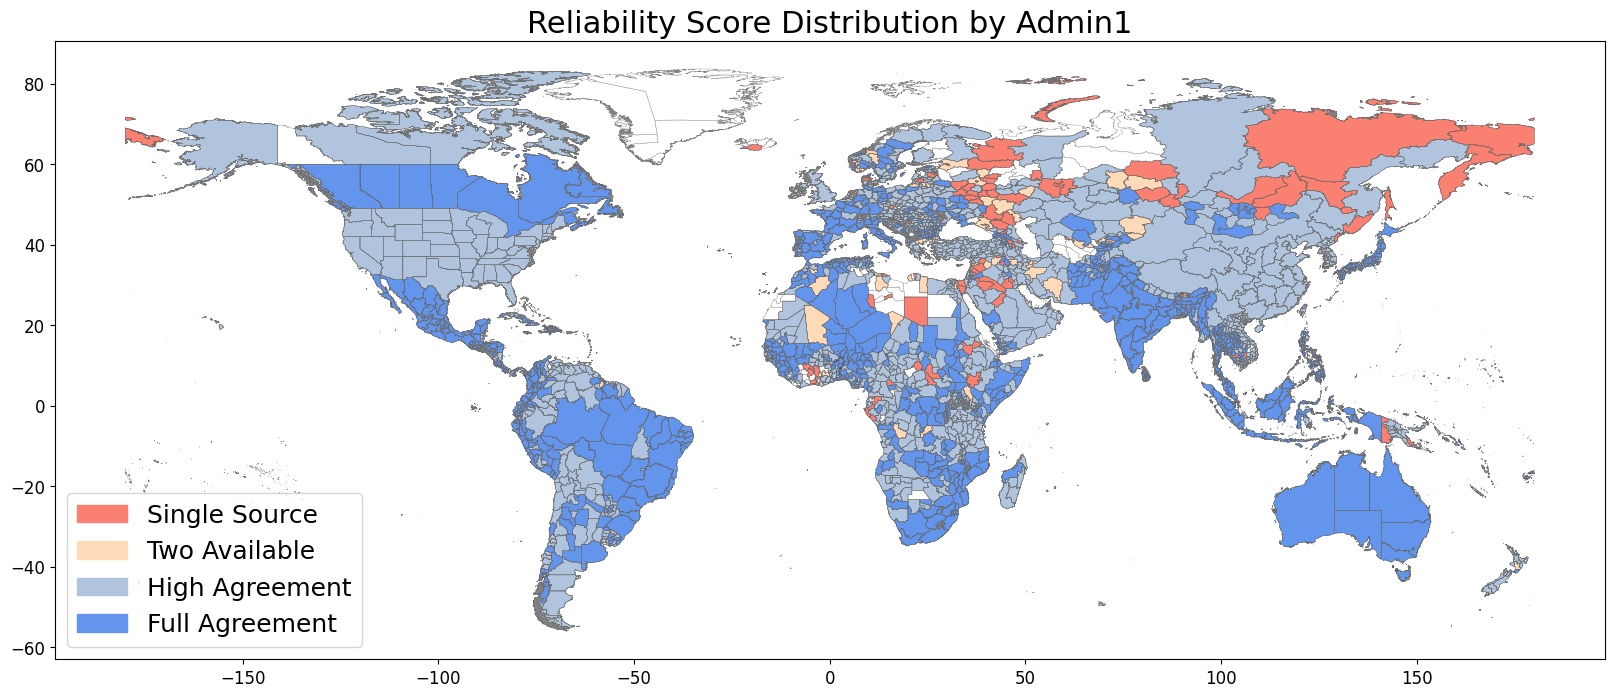

In [15]:
rel = gpd.GeoDataFrame(rel, geometry="geometry")

reliability_colors = {
    1: 'salmon',
    2: 'peachpuff',
    3: 'lightsteelblue',
    4: 'cornflowerblue'
}

fig, ax = plt.subplots(1, 1, figsize=(20, 15))
gadm1.boundary.plot(ax=ax, linewidth=0.2, color='grey')

rel.plot(
    ax=ax,
    color=[reliability_colors[r] for r in rel['reliability']],
    edgecolor='black',
    linewidth=0.2
)

labels = [
    'Single Source',
    'Two Available',
    'High Agreement',
    'Full Agreement'
]

legend_patches = [mpatches.Patch(color=reliability_colors[i], label=label) for i, label in enumerate(labels, start=1)]
ax.legend(handles=legend_patches, loc='lower left', fontsize=18, title='', title_fontsize='13')

plt.title('Reliability Score Distribution by Admin1', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=12)

plt.show()
